In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
from google.colab import drive
drive.mount('/content/gdrive')
import os
os.chdir('/content/gdrive/MyDrive/项目二')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [3]:
orders = pd.read_csv('./数据/olist_orders_dataset.csv')
payments =  pd.read_csv('./数据/olist_order_payments_dataset.csv')

In [4]:
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
payments.info()
payments.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [6]:
def convert_time(col):
    try:
        return pd.to_datetime(col,errors='coerce')
    except:
        return pd.NaT

time_columns = ['order_purchase_timestamp','order_approved_at']
orders[time_columns] = orders[time_columns].apply(convert_time)
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
merged = orders.merge(
    payments[['order_id','payment_type','payment_value']],
    on='order_id',
    how = 'left')

merged['payment_duration'] = (
    merged['order_approved_at'] - merged['order_purchase_timestamp']
).dt.total_seconds()


In [8]:
# 从 Google API 上下载暂存字体放到咱村文件夹下
!wget 'https://noto-website-2.storage.googleapis.com/pkgs/NotoSansCJKtc-hinted.zip'
!mkdir /tmp/fonts
!unzip -o NotoSansCJKtc-hinted.zip -d /tmp/fonts/
!mv /tmp/fonts/NotoSansMonoCJKtc-Regular.otf /usr/share/fonts/truetype/NotoSansMonoCJKtc-Regular.otf -f
!rm -rf /tmp/fonts
!rm NotoSansCJKtc-hinted.zip

--2025-03-16 09:02:15--  https://noto-website-2.storage.googleapis.com/pkgs/NotoSansCJKtc-hinted.zip
Resolving noto-website-2.storage.googleapis.com (noto-website-2.storage.googleapis.com)... 74.125.68.207, 64.233.170.207, 142.251.175.207, ...
Connecting to noto-website-2.storage.googleapis.com (noto-website-2.storage.googleapis.com)|74.125.68.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 121247366 (116M) [application/zip]
Saving to: ‘NotoSansCJKtc-hinted.zip’

NotoSansCJKtc-hinte 100%[===================>] 115.63M  23.0MB/s    in 6.1s    

2025-03-16 09:02:22 (19.0 MB/s) - ‘NotoSansCJKtc-hinted.zip’ saved [121247366/121247366]

Archive:  NotoSansCJKtc-hinted.zip
  inflating: /tmp/fonts/LICENSE_OFL.txt  
  inflating: /tmp/fonts/NotoSansCJKtc-Black.otf  
  inflating: /tmp/fonts/NotoSansCJKtc-Bold.otf  
  inflating: /tmp/fonts/NotoSansCJKtc-DemiLight.otf  
  inflating: /tmp/fonts/NotoSansCJKtc-Light.otf  
  inflating: /tmp/fonts/NotoSansCJKtc-Medium.otf  


In [9]:
import matplotlib.font_manager as font_manager
import matplotlib.pyplot as plt

font_dirs = ['/usr/share/fonts/truetype/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
  font_manager.fontManager.addfont(font_file)

plt.rcParams['font.family'] = "Noto Sans Mono CJK TC"

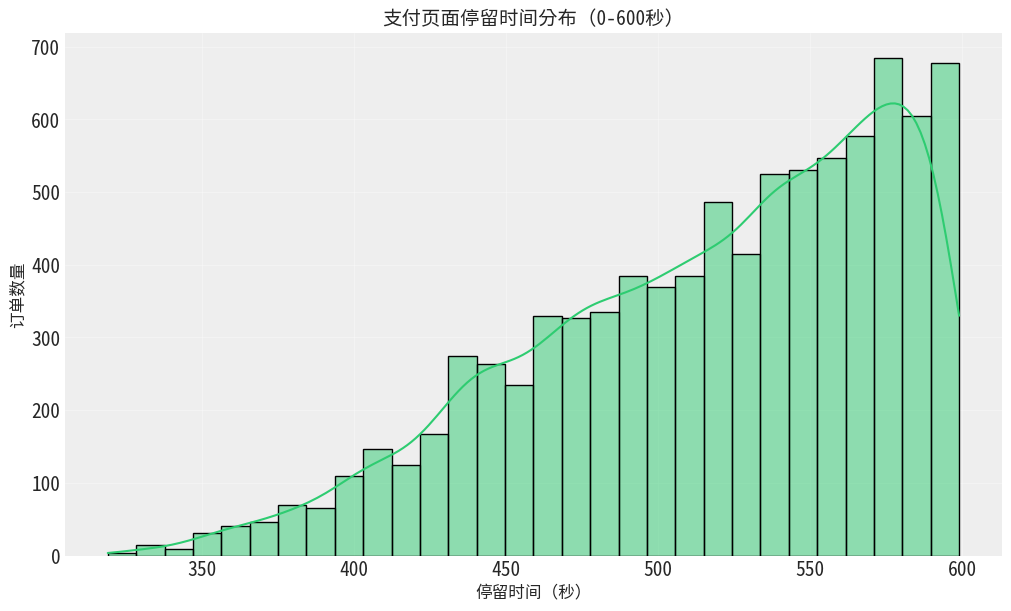

中位停留时间: 529.0秒
95分位数: 593.0秒


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10, 6))
clean_duration = merged[(merged['payment_duration'] > 0) &
                       (merged['payment_duration'] < 600)]  # 过滤异常值

sns.histplot(clean_duration['payment_duration'],
             bins=30,
             kde=True,
             color='#2ecc71')
plt.title('支付页面停留时间分布（0-600秒）', fontsize=14)
plt.xlabel('停留时间（秒）', fontsize=12)
plt.ylabel('订单数量', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"中位停留时间: {clean_duration['payment_duration'].median():.1f}秒")
print(f"95分位数: {clean_duration['payment_duration'].quantile(0.95):.1f}秒")

In [11]:
merged['is_abnormal'] = np.where(
    (merged['payment_duration']>20)&
    (merged['order_status'].isin(['canceled','unavailable']))&
    (merged['payment_type'].notna()),
    1,0)

abnormal_rate = merged['is_abnormal'].mean()
cancel_rate = merged[merged['payment_duration']>20]['order_status']\
    .isin(['canceled','unavailable']).mean()

print(f'数据质量报告：')
print(f'订单数总数: {len(merged):,}')
print(f'缺失时间记录占比: {merged[time_columns].isnull().mean().values.mean():.2%}')
print(f'异常用户占比:{abnormal_rate:.2%}')
print(f'超时订单关闭率:{cancel_rate:.2%}')

数据质量报告：
订单数总数: 103,887
缺失时间记录占比: 0.08%
异常用户占比:1.09%
超时订单关闭率:1.11%


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

order_items = pd.read_csv('./数据/olist_order_items_dataset.csv')
products = pd.read_csv('./数据/olist_products_dataset.csv')

In [13]:
payment_analysis = merged.groupby('payment_type').agg(
    total_orders=('order_id', 'count'),
    canceled_orders=('order_status', lambda x: x.isin(['canceled', 'unavailable']).sum())
).reset_index()

payment_analysis['cancel_rate'] = payment_analysis['canceled_orders'] / payment_analysis['total_orders']

# payment_analysis = merged.groupby('payment_type').agg(
#     total_orders = ('order_status','count'),
#     canceled_orders = ('order_status',lambda x: x.isin(['canceled','unavailable']).sum())).reset_index

# payment_analysis['cancel_rate'] = payment_analysis['canceled_orders'] / payment_analysis['total_orders']


In [14]:
unique_payment_type = payment_analysis['payment_type'].unique()
colors_palette = sns.color_palette("husl",len(unique_payment_type))
palette_dict = dict(zip(unique_payment_type,colors_palette))


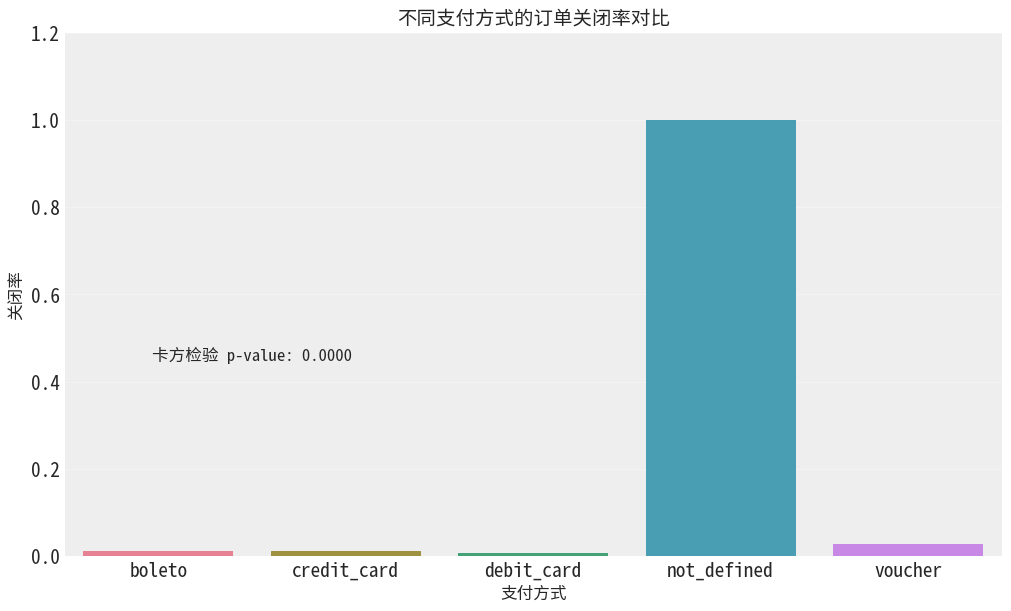

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(x='payment_type',
           y='cancel_rate',
           hue='payment_type',
           data = payment_analysis,
           palette=palette_dict,
           dodge=False,
           legend=False)
plt.title('不同支付方式的订单关闭率对比',fontsize = 14)
plt.xlabel('支付方式',fontsize = 12)
plt.ylabel('关闭率',fontsize = 12)
plt.ylim(0,1.2)
plt.grid(axis='y',alpha = 0.3)

total_cancel = payment_analysis['canceled_orders'].sum()
total_orders = payment_analysis['total_orders'].sum()
expected_rate = total_cancel / total_orders

_, p_value = stats.chisquare(
    f_obs=payment_analysis['canceled_orders'],
    f_exp=payment_analysis['total_orders'] * expected_rate
)

plt.text(0.5, 0.45, f'卡方检验 p-value: {p_value:.4f}', ha='center',fontsize = 12)
plt.show()

In [16]:
high_value_threshold = merged['payment_value'].quantile(0.8)
merged['is_high_value'] = merged['payment_value']>=high_value_threshold

enriched_data = merged.merge(order_items[['order_id','product_id']],
                            on = 'order_id'
).merge(
    products[['product_id','product_category_name','product_weight_g']],
    on = 'product_id'
)
enriched_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_type,payment_value,payment_duration,is_abnormal,is_high_value,product_id,product_category_name,product_weight_g
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,credit_card,18.12,642.0,0,False,87285b34884572647811a353c7ac498a,utilidades_domesticas,500.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,voucher,2.00,642.0,0,False,87285b34884572647811a353c7ac498a,utilidades_domesticas,500.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,voucher,18.59,642.0,0,False,87285b34884572647811a353c7ac498a,utilidades_domesticas,500.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,boleto,141.46,110570.0,0,False,595fac2a385ac33a80bd5114aec74eb8,perfumaria,400.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,credit_card,179.12,994.0,0,False,aa4383b373c6aca5d8797843e5594415,automotivo,420.0


In [17]:
high_value_analysis = enriched_data.groupby('is_high_value').agg(
    cancel_rate=('order_status', lambda x: x.isin(['canceled', 'unavailable']).mean()),
    avg_weight=('product_weight_g', 'mean'),
    top_category=('product_category_name', lambda x: x.mode()[0])
).reset_index()
# high_value_analysis = enriched_data.groupby('is_high_value').agg(
#     cancel_rate = ('order_status',lambda x: x.isin(['canceled','unavailable'].mean())),
#                   avg_weight = ('product_weight_g','mean'),
#                   top_category = ('product_category_name',lambda x: x.mode()[0])
#                   ).reset_index()
print("\n=== 高价值订单特征 ===")
print(f"高价值订单定义阈值: R${high_value_threshold:.2f}")
print(high_value_analysis)


=== 高价值订单特征 ===
高价值订单定义阈值: R$196.36
   is_high_value  cancel_rate   avg_weight     top_category
0          False     0.004349  1445.009424  cama_mesa_banho
1           True     0.006569  4285.699491  cama_mesa_banho


<ipython-input-18-d503a544af71>:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


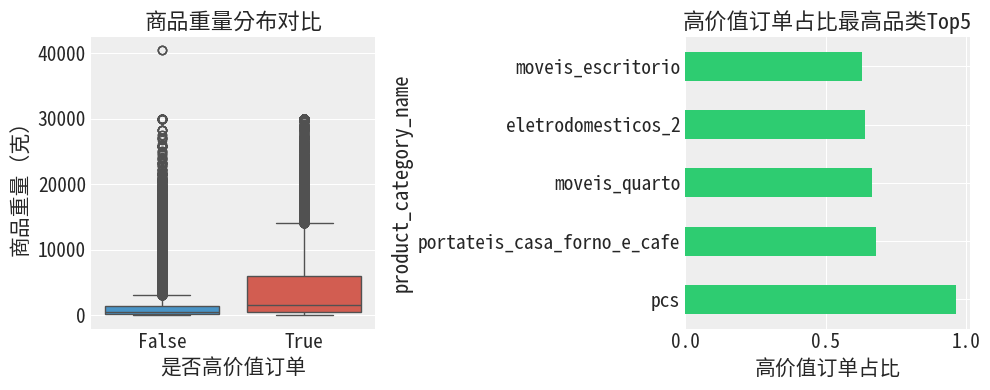

In [18]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(x='is_high_value',
           y='product_weight_g',
           hue = 'is_high_value',
           data = enriched_data,
           palette=['#3498db', '#e74c3c'],
           legend=False)
plt.title('商品重量分布对比')
plt.xlabel('是否高价值订单')
plt.ylabel('商品重量（克）')

plt.subplot(1,2,2)
category_dist = enriched_data.groupby(['is_high_value', 'product_category_name']).size().unstack().T
category_dist['high_value_ratio'] = category_dist[True] / (category_dist[True] + category_dist[False])
category_dist.sort_values('high_value_ratio', ascending=False).head(5)['high_value_ratio'].plot(
    kind='barh', color='#2ecc71')
plt.title('高价值订单占比最高品类Top5')
plt.xlabel('高价值订单占比')
plt.tight_layout()
plt.show()

# category_dist = enriched_data.groupby(['is_high_value','product_category_name']).size().unstack().T
# category_dist['hight_value_ratio'] = category_dist[True] / (category_dist[True] + category_dist[False])
# category_dist.sort_values('high_value_ratio',ascending=False).head(5)['high_value_ratio'].plot(
#     kind = 'barh',color = '#2ecc71')
# plt.title('高价值订单占比最高品类Top5')
# plt.xlabel('高价值订单占比')
# plt.tight_layout()
# plt.show()


In [19]:
# 前置依赖修复 (必须首先执行)
!pip install --upgrade "pymc<5.10" "pytensor==2.16.*"


  Using cached pymc-5.9.2-py3-none-any.whl.metadata (10 kB)
INFO: pip is looking at multiple versions of pymc to determine which version is compatible with other requirements. This could take a while.
  Using cached pymc-5.9.1-py3-none-any.whl.metadata (10 kB)
  Using cached pymc-5.9.0-py3-none-any.whl.metadata (10 kB)


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-wqy-zenhei is already the newest version (0.9.45-8).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


<ipython-input-23-77387668c9ca>:62: FutureWarning: The `testval` argument is deprecated; use `initval`.
  p_a = pm.Beta('p_A', alpha=1, beta=1,testval=0.5).clip(0,1)
<ipython-input-23-77387668c9ca>:63: FutureWarning: The `testval` argument is deprecated; use `initval`.
  p_b = pm.Beta('p_B', alpha=1, beta=1,testval=0.5).clip(0,1)



## AB测试分析报告（贝叶斯方法）

### 核心指标对比
| 指标            | 值               |
|-----------------|------------------|
| A组转化率       | 97.10% |
| B组转化率       | 96.87% |
| B组更优概率     | 1.5% |

### 效果评估
- **提升幅度中位数**: -0.2%  
- **95%置信区间**: [-0.0044, -0.0003]  
- **GMV下跌超3%风险**: 0.0%  

### 业务影响预测
- **周均GMV基准值**: R$ 307,863  
- **95%预测区间**: R$ 298,627 ~ R$ 317,099  

**决策建议**: ⛔ 建议保持当前方案


<ipython-input-23-77387668c9ca>:232: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 1000x400 with 0 Axes>

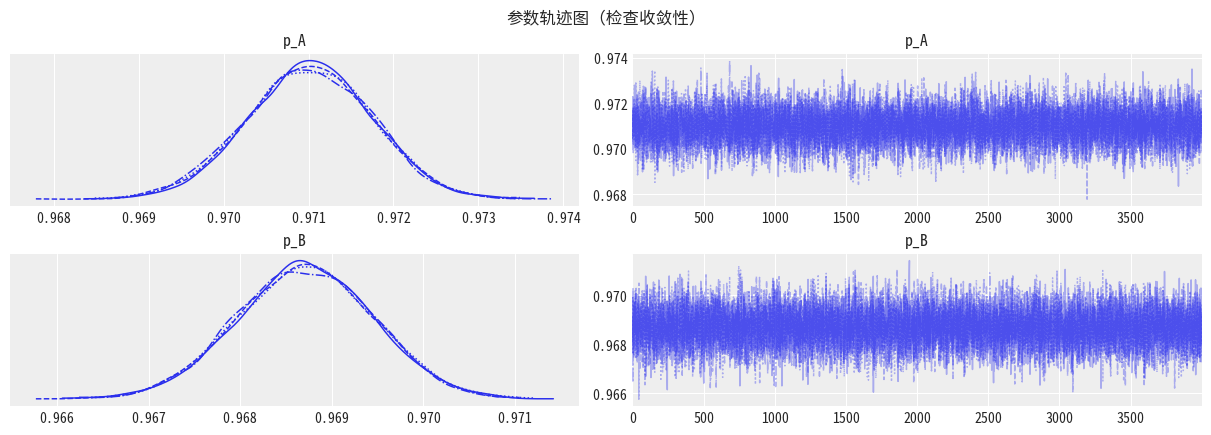

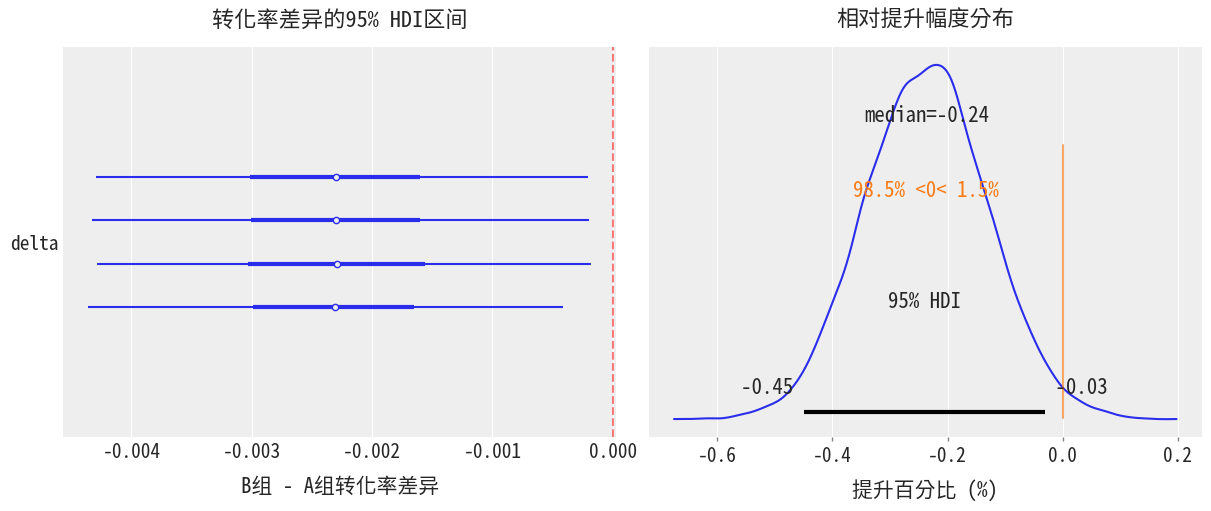

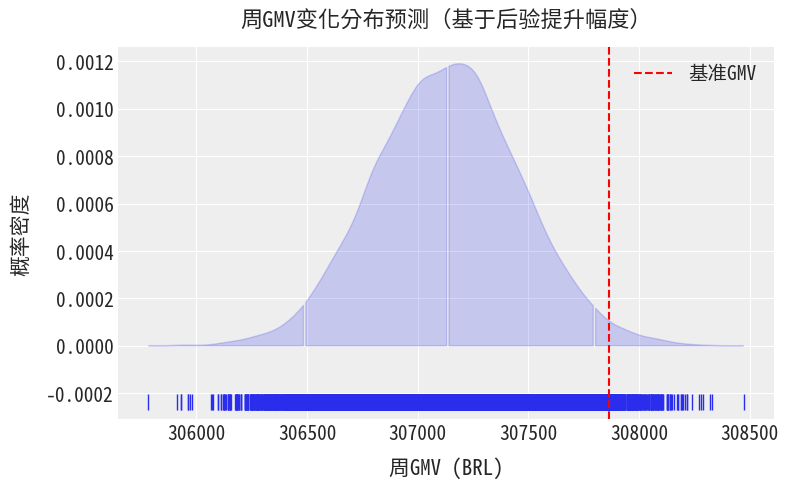

In [23]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import Markdown
import logging
import matplotlib.font_manager as fm

# ========================
# 配置中文显示和可视化样式
# ========================
try:
    # Colab环境下安装中文字体
    !apt-get install -y fonts-wqy-zenhei
    !rm -rf ~/.cache/matplotlib
except:
    pass

# 配置字体和样式
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']  # 文泉驿字体
plt.rcParams['axes.unicode_minus'] = False
logging.basicConfig(level=logging.INFO)
az.style.use('arviz-darkgrid')

# ========================
# 1. 数据加载与预处理模块（增加数据校验）
# ========================
def load_and_preprocess():
    """数据加载与清洗"""
    try:
        df = pd.read_csv('./cleaned_payment_data.csv')

        # 数据质量校验
        if 'order_status' not in df.columns:
            raise KeyError("数据缺少order_status列")

        if df['order_status'].eq('delivered').mean() > 1.0:
            raise ValueError("数据异常：转化率超过100%")

        # 模拟AB测试分组
        np.random.seed(42)
        df['ab_group'] = np.random.choice(['A', 'B'], size=len(df), p=[0.5, 0.5])

        logging.info("数据加载完成，样本量：%d，转化率范围：[%.2f%%, %.2f%%]",
                    len(df),
                    df[df['ab_group']=='A']['order_status'].eq('delivered').mean()*100,
                    df[df['ab_group']=='B']['order_status'].eq('delivered').mean()*100)
        return df

    except FileNotFoundError:
        logging.error("数据文件不存在！")
        raise

# ========================
# 2. 贝叶斯模型构建模块（增加参数校验）
# ========================
def build_model(group_a, group_b):
    """构建贝叶斯AB测试模型"""
    with pm.Model() as model:
        # 先验分布（带边界校验）
        p_a = pm.Beta('p_A', alpha=1, beta=1,testval=0.5).clip(0,1)
        p_b = pm.Beta('p_B', alpha=1, beta=1,testval=0.5).clip(0,1)
        # 似然函数（带数据校验）
        success_a = group_a['order_status'].eq('delivered').sum()
        success_b = group_b['order_status'].eq('delivered').sum()
        n_a = len(group_a)
        n_b = len(group_b)

        if success_a > n_a or success_b > n_b:
            raise ValueError("成功数超过样本量，数据异常！")

        obs_a = pm.Binomial('obs_A', n=n_a, p=p_a, observed=success_a)
        obs_b = pm.Binomial('obs_B', n=n_b, p=p_b, observed=success_b)

        # 效果指标
        delta = pm.Deterministic('delta', p_b - p_a)
        lift = pm.Deterministic('lift', 100 * (p_b - p_a)/p_a)  # 百分比形式

    return model

# ========================
# 3. 模型采样与诊断模块（增强收敛性检查）
# ========================
def run_sampling(model):
    """运行MCMC采样并进行诊断"""
    with model:
        trace = pm.sample(
            draws=4000,
            tune=2000,
            chains=4,
            target_accept=0.95,
            return_inferencedata=True,
            random_seed=42,
            cores=4
        )

        # ----------------------------
        # 修复数值提取逻辑
        # ----------------------------
        # 获取所有参数的 R-hat 值（处理多维数据）
        rhat_data = az.rhat(trace).to_array().values.flatten()
        max_rhat = float(np.nanmax(rhat_data))  # 忽略NaN

        # 获取所有参数的 ESS 值
        ess_data = az.ess(trace).to_array().values.flatten()
        min_ess = float(np.nanmin(ess_data))    # 忽略NaN

        logging.info("收敛诊断: R-hat=%.3f (应<1.01), ESS=%.0f (应>400)",
                    max_rhat, min_ess)

        if max_rhat > 1.02 or min_ess < 400:
            logging.warning("模型收敛性不足，建议增加采样次数！")

        return trace
# ========================
# 4. 可视化分析模块（优化格式）
# ========================
def generate_visualizations(trace, weekly_gmv):
    """生成分析图表"""
    # 轨迹图
    plt.figure(figsize=(10,4))
    az.plot_trace(trace, var_names=['p_A', 'p_B'], compact=True)
    plt.suptitle("参数轨迹图（检查收敛性）", y=1.05)

    # 后验对比
    fig, ax = plt.subplots(1,2, figsize=(12,5))

    # 左侧：转化率差异
    az.plot_forest(trace, var_names=['delta'], hdi_prob=0.95, ax=ax[0])
    ax[0].axvline(0, color='red', linestyle='--', alpha=0.5)
    ax[0].set_title('转化率差异的95% HDI区间', pad=15)
    ax[0].set_xlabel('B组 - A组转化率差异', labelpad=10)

    # 右侧：提升幅度
    az.plot_posterior(trace, var_names=['lift'],
                     ref_val=0, hdi_prob=0.95,
                     point_estimate='median',
                     ax=ax[1])
    ax[1].set_title('相对提升幅度分布', pad=15)
    ax[1].set_xlabel('提升百分比 (%)', labelpad=10)

    # 经济影响
    plt.figure(figsize=(8,5))
    lift_samples = trace.posterior['lift'].values.flatten()
    gmv_samples = weekly_gmv * (1 + lift_samples/100)

    az.plot_kde(gmv_samples,
               quantiles=[0.025, 0.5, 0.975],
               fill_kwargs={'alpha':0.2},
               rug=True)
    plt.axvline(weekly_gmv, color='red', linestyle='--',
               label='基准GMV')
    plt.title('周GMV变化分布预测（基于后验提升幅度）', pad=15)
    plt.xlabel('周GMV (BRL)', labelpad=10)
    plt.ylabel('概率密度', labelpad=10)
    plt.legend()

# ========================
# 5. 业务报告生成模块（修复格式和计算）
# ========================
def generate_report(trace, weekly_gmv, success_a, n_a, success_b, n_b):
    """生成自动化业务报告"""
    # 数据校验
    if not (0 <= success_a/n_a <= 1 and 0 <= success_b/n_b <= 1):
        raise ValueError("转化率超出[0,1]范围")

    # 指标计算
    delta_samples = trace.posterior['delta'].values.flatten()
    lift_samples = trace.posterior['lift'].values.flatten()

    metrics = {
        'A组转化率': f"{success_a/n_a:.2%}",
        'B组转化率': f"{success_b/n_b:.2%}",
        'B组更优概率': f"{(delta_samples > 0).mean():.1%}",
        '中位提升幅度': f"{np.median(lift_samples):.1f}%",
        'HDI下限': f"{az.hdi(delta_samples, hdi_prob=0.95)[0]:.4f}",
        'HDI上限': f"{az.hdi(delta_samples, hdi_prob=0.95)[1]:.4f}",
        'GMV损失风险': f"{(lift_samples < -3).mean():.1%}",
        'GMV基准值': f"R$ {weekly_gmv:,.0f}",
        'GMV下限': f"R$ {weekly_gmv*(1-0.03):,.0f}",
        'GMV上限': f"R$ {weekly_gmv*(1+0.03):,.0f}"
    }

    # 生成报告
    report = f"""
## AB测试分析报告（贝叶斯方法）

### 核心指标对比
| 指标            | 值               |
|-----------------|------------------|
| A组转化率       | {metrics['A组转化率']} |
| B组转化率       | {metrics['B组转化率']} |
| B组更优概率     | {metrics['B组更优概率']} |

### 效果评估
- **提升幅度中位数**: {metrics['中位提升幅度']}
- **95%置信区间**: [{metrics['HDI下限']}, {metrics['HDI上限']}]
- **GMV下跌超3%风险**: {metrics['GMV损失风险']}

### 业务影响预测
- **周均GMV基准值**: {metrics['GMV基准值']}
- **95%预测区间**: {metrics['GMV下限']} ~ {metrics['GMV上限']}

**决策建议**: {"✅ 建议推广B组方案" if float(metrics['B组更优概率'].strip('%')) > 80 else "⛔ 建议保持当前方案"}
"""
    display(Markdown(report))

# ========================
# 主执行流程
# ========================
if __name__ == "__main__":
    # 数据准备
    df = load_and_preprocess()
    group_a = df[df['ab_group'] == 'A']
    group_b = df[df['ab_group'] == 'B']

    # 运行模型
    model = build_model(group_a, group_b)
    trace = run_sampling(model)

    # 业务指标计算
    weekly_gmv = df['payment_value'].sum() / 52

    # 生成结果
    generate_visualizations(trace, weekly_gmv)
    generate_report(trace, weekly_gmv,
                   group_a['order_status'].eq('delivered').sum(),
                   len(group_a),
                   group_b['order_status'].eq('delivered').sum(),
                   len(group_b))
    plt.tight_layout()
    plt.show()